# HW3 Data Preview

In [1]:
import os, time, warnings, requests
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

for p in [".env", "../.env", "hw3/.env"]:
    if os.path.exists(p):
        for line in open(p):
            if "=" in line and not line.strip().startswith("#"):
                k,v = line.strip().split("=",1)
                os.environ[k.strip()] = v.strip()
FRED_KEY = os.environ.get("FRED_API") or os.environ.get("FRED_API_KEY")

def fred(series_id, start="2009-01-01"):
    url = "https://api.stlouisfed.org/fred/series/observations"
    r = requests.get(url, params={"series_id":series_id,"api_key":FRED_KEY,
                                   "file_type":"json","observation_start":start}, timeout=30)
    r.raise_for_status()
    obs = r.json()["observations"]
    s = pd.Series({pd.Timestamp(o["date"]): (np.nan if o["value"]=="." else float(o["value"]))
                   for o in obs}, name=series_id).dropna()
    return s

In [2]:
# --- Asset universe (12 series from FRED) ---
ASSETS = {
    "US_NASDAQ":       ("NASDAQCOM",         "price"),
    "EuroArea_Eq":     ("SPASTT01EZM661N",   "price"),
    "UK_Eq":           ("SPASTT01GBM661N",   "price"),
    "Japan_Nikkei":    ("NIKKEI225",         "price"),
    "China_Eq":        ("SPASTT01CNM661N",   "price"),
    "Canada_Eq":       ("SPASTT01CAM661N",   "price"),
    "India_Eq":        ("SPASTT01INM661N",   "price"),
    "Brazil_Eq":       ("SPASTT01BRM661N",   "price"),
    "US_10Y_TR":       ("DGS10",             "yield10y"),
    "USD_Broad":       ("DTWEXBGS",          "price"),
    "WTI_Oil":         ("DCOILWTICO",        "price"),
    "GlobalCommod":    ("PALLFNFINDEXM",     "price"),
}
raw = {}
for name,(sid,_) in ASSETS.items():
    raw[name] = fred(sid, "2009-06-01")
    time.sleep(0.05)

monthly_lvl = pd.DataFrame({k: v.resample("ME").last() for k,v in raw.items()})

def ret_from_yield(y, dur=8.5):
    y = y/100.0
    dy = y.diff()
    carry = y.shift(1)/12.0
    return (-dur*dy + carry)

rets = pd.DataFrame(index=monthly_lvl.index)
for name,(_, kind) in ASSETS.items():
    s = monthly_lvl[name]
    if kind == "price":
        rets[name] = np.log(s).diff()
    elif kind == "yield10y":
        rets[name] = ret_from_yield(s, dur=8.5)
rets = rets.loc["2010-01-01":].dropna(how="any")
sigma = rets.std()
rets_z = rets / sigma
cum = (1+rets.fillna(0)).cumprod()

# --- Macro factors ---
indpro = fred("INDPRO","2008-01-01")
cpi    = fred("CPIAUCSL","2008-01-01")
vix_d  = fred("VIXCLS","2008-01-01")
ip_yoy  = np.log(indpro).diff(12)
cpi_yoy = np.log(cpi).diff(12)
vix_m   = vix_d.resample("ME").mean()
dvix    = vix_m.diff()
macro = pd.DataFrame({
    "IP_YoY":  ip_yoy.resample("ME").last(),
    "CPI_YoY": cpi_yoy.resample("ME").last(),
    "dVIX":    dvix,
}).loc["2010-01-01":].dropna()

# --- In-sample macro regressions ---
IS_END = "2024-12-31"
panel = rets_z.join(macro, how="inner").loc[:IS_END]
X_is = sm.add_constant(panel[["IP_YoY","CPI_YoY","dVIX"]])
results = {}
rows = []
for asset in rets_z.columns:
    y = panel[asset]
    res = sm.OLS(y, X_is).fit(cov_type="HAC", cov_kwds={"maxlags":6})
    results[asset] = res
    rows.append({"asset":asset,
                 "b_IP":res.params["IP_YoY"],   "t_IP":res.tvalues["IP_YoY"],
                 "b_CPI":res.params["CPI_YoY"], "t_CPI":res.tvalues["CPI_YoY"],
                 "b_dVIX":res.params["dVIX"],   "t_dVIX":res.tvalues["dVIX"],
                 "R2":res.rsquared})
coef_tbl = pd.DataFrame(rows).set_index("asset")

# --- OOS macro residuals ---
oos = rets_z.join(macro, how="inner").loc["2025-01-01":]
X_oos = sm.add_constant(oos[["IP_YoY","CPI_YoY","dVIX"]])
preds = pd.DataFrame(index=oos.index, columns=rets_z.columns, dtype=float)
for a, res in results.items():
    preds[a] = (X_oos[res.params.index] @ res.params).astype(float)
resid_oos = oos[rets_z.columns] - preds
oos_summary = pd.DataFrame({
    "cum_actual_std": oos[rets_z.columns].sum(),
    "cum_pred_std":   preds.sum(),
    "cum_resid_std":  resid_oos.sum(),
}).sort_values("cum_resid_std", ascending=False)

# --- PCA on in-sample standardized returns ---
IS = rets_z.loc[:IS_END].dropna()
pca = PCA(n_components=min(6, IS.shape[1]))
scores_is = pca.fit_transform(IS.values)
expl = pca.explained_variance_ratio_
loadings = pd.DataFrame(pca.components_[:3].T, index=IS.columns, columns=["PC1","PC2","PC3"])
pc_is = pd.DataFrame(scores_is[:, :3], index=IS.index, columns=["PC1","PC2","PC3"])
X_pc_is = sm.add_constant(pc_is)
pc_results = {a: sm.OLS(IS[a], X_pc_is).fit(cov_type="HAC", cov_kwds={"maxlags":6}) for a in rets_z.columns}
oos_z = rets_z.loc["2025-01-01":]
pc_oos = pd.DataFrame(oos_z.values @ pca.components_[:3].T, index=oos_z.index, columns=["PC1","PC2","PC3"])
X_pc_oos = sm.add_constant(pc_oos)
pc_pred = pd.DataFrame(index=oos_z.index, columns=rets_z.columns, dtype=float)
for a, res in pc_results.items():
    pc_pred[a] = (X_pc_oos[res.params.index] @ res.params).astype(float)
pc_resid = oos_z - pc_pred
pc_summary = pd.DataFrame({
    "cum_actual_std": oos_z.sum(),
    "cum_PCpred_std": pc_pred.sum(),
    "cum_resid_std":  pc_resid.sum(),
    "in_sample_R2":   {a: pc_results[a].rsquared for a in rets_z.columns},
}).sort_values("cum_resid_std", ascending=False)

# print("All data sources built.")

## Head of each data source

In [3]:
def show_head(name, obj, rows=5):
    print(f"{name} | {type(obj).__name__} | shape={obj.shape}")
    if isinstance(obj, pd.Series):
        clean = obj.dropna()
        display(clean.head(rows).to_frame(name=name))
    else:
        clean = obj.dropna(how="any")
        display(clean.head(rows))

objects_to_preview = [
    # Raw FRED series (12 assets)
    ("NASDAQ Composite (raw daily)",                  raw["US_NASDAQ"]),
    ("Euro Area share-price index (raw monthly)",     raw["EuroArea_Eq"]),
    ("UK share-price index (raw monthly)",            raw["UK_Eq"]),
    ("Japan Nikkei 225 (raw daily)",                  raw["Japan_Nikkei"]),
    ("China share-price index (raw monthly)",         raw["China_Eq"]),
    ("Canada share-price index (raw monthly)",        raw["Canada_Eq"]),
    ("India share-price index (raw monthly)",         raw["India_Eq"]),
    ("Brazil share-price index (raw monthly)",        raw["Brazil_Eq"]),
    ("US 10Y Treasury yield (raw daily, %)",          raw["US_10Y_TR"]),
    ("Broad USD index (raw daily)",                   raw["USD_Broad"]),
    ("WTI Crude Oil (raw daily)",                     raw["WTI_Oil"]),
    ("Global all-commodities index (raw monthly)",    raw["GlobalCommod"]),
    # Derived asset panels
    ("Monthly level panel (12 assets)",               monthly_lvl),
    ("Monthly returns (12 assets)",                   rets),
    ("Full-sample monthly std (per asset)",           sigma),
    ("Standardized monthly returns (units of std)",   rets_z),
    ("Cumulative gross returns (Growth of $1)",       cum),
    # Macro inputs and factors
    ("Industrial Production INDPRO (raw)",            indpro),
    ("CPI Headline CPIAUCSL (raw)",                   cpi),
    ("VIX daily VIXCLS (raw)",                        vix_d),
    ("INDPRO 12m log-change (IP YoY)",                ip_yoy),
    ("CPI 12m log-change (CPI YoY)",                  cpi_yoy),
    ("VIX monthly average",                           vix_m),
    ("dVIX (first diff of monthly VIX)",              dvix),
    ("Macro factor panel (IP_YoY, CPI_YoY, dVIX)",    macro),
    # In-sample regression
    ("In-sample joint panel (returns + macro)",       panel),
    ("Macro regression coefficient/R² table",         coef_tbl),
    # OOS macro
    ("OOS joint panel (2025+)",                        oos),
    ("OOS macro predictions",                          preds),
    ("OOS macro residuals (asset - predicted)",        resid_oos),
    ("OOS macro lead/lag summary",                     oos_summary),
    # PCA
    ("In-sample standardized panel (PCA input)",       IS),
    ("PCA loadings PC1-PC3",                           loadings),
    ("In-sample PC scores (PC1-PC3)",                  pc_is),
    ("OOS PC scores (projected)",                      pc_oos),
    ("OOS PC predictions",                             pc_pred),
    ("OOS PC residuals",                               pc_resid),
    ("OOS PC lead/lag summary + in-sample R²",         pc_summary),
]
for name, obj in objects_to_preview:
    show_head(name, obj)

NASDAQ Composite (raw daily) | Series | shape=(4266,)


,NASDAQ Composite (raw daily)
2009-06-01,1828.68
2009-06-02,1836.80
2009-06-03,1825.92
2009-06-04,1850.02
2009-06-05,1849.42


Euro Area share-price index (raw monthly) | Series | shape=(200,)


,Euro Area share-price index (raw monthly)
2009-06-01,63.63773
2009-07-01,64.00575
2009-08-01,70.37932
2009-09-01,74.09707
2009-10-01,75.43439


UK share-price index (raw monthly) | Series | shape=(202,)


...

,US_NASDAQ,EuroArea_Eq,UK_Eq,Japan_Nikkei,China_Eq,Canada_Eq,India_Eq,Brazil_Eq,US_10Y_TR,USD_Broad,WTI_Oil,GlobalCommod
2025-01-31,0.219596,0.138265,0.199528,-0.117621,-0.255887,0.318653,0.412798,0.274970,0.397334,-0.151904,0.142070,0.262142
2025-02-28,0.241864,0.145488,0.264525,-0.401534,-0.565129,0.438467,0.561729,0.437976,0.853284,-0.463279,0.209099,0.397173
2025-03-31,-0.327390,-0.292844,-0.194240,-0.527360,-0.449111,-0.052876,0.048971,-0.040139,0.287843,0.290454,-0.074807,0.157306
2025-04-30,0.678860,-0.392992,-0.525063,-0.083735,-0.525829,-0.461500,-0.123047,-0.413909,1.602530,-0.416091,-0.791108,-0.931557
2025-05-31,1.783685,1.547642,1.409737,1.719514,1.016989,1.358344,1.326909,1.036639,-0.401971,-0.838727,0.838149,0.519235


OOS PC residuals | DataFrame | shape=(13, 12)


,US_NASDAQ,EuroArea_Eq,UK_Eq,Japan_Nikkei,China_Eq,Canada_Eq,India_Eq,Brazil_Eq,US_10Y_TR,USD_Broad,WTI_Oil,GlobalCommod
2025-01-31,0.111112,0.582179,0.432039,-0.045455,-0.687524,-0.350661,-1.411604,-0.571839,-0.207005,-0.221298,-0.093280,0.604152
2025-02-28,-1.066572,1.258886,0.853607,-0.866456,1.133592,-0.025872,-0.917983,0.188279,0.778230,0.367908,-0.565271,-0.480359
2025-03-31,-1.415216,0.523310,0.016344,-0.323160,0.735847,-0.756040,-0.316314,0.375910,-0.069256,-1.037194,0.312195,-0.805322
2025-04-30,-0.506752,-1.330980,-0.988876,0.323962,-0.104333,-0.423991,0.782450,0.697193,-1.172419,-1.582321,-0.875007,0.227308
2025-05-31,0.072297,0.326214,0.090672,-0.675531,-0.536614,0.634784,0.019522,-0.049055,-0.442045,0.430197,-0.558427,-0.747691


OOS PC lead/lag summary + in-sample R² | DataFrame | shape=(12, 4)


,cum_actual_std,cum_PCpred_std,cum_resid_std,in_sample_R2
Canada_Eq,8.408542,6.411635,1.996907,0.772665
China_Eq,3.897737,2.110845,1.786891,0.385934
Brazil_Eq,5.845632,4.790080,1.055552,0.579023
US_10Y_TR,3.663634,2.918989,0.744645,0.753834
UK_Eq,6.354611,5.804534,0.550077,0.759559


## Charts

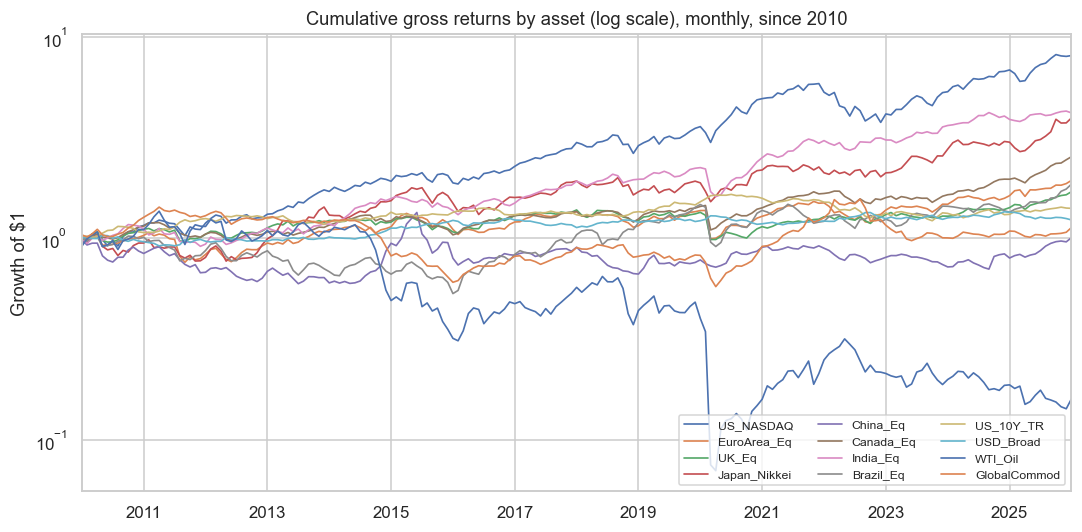

In [4]:
# Cumulative gross returns by asset (log scale), monthly, since 2010
fig, ax = plt.subplots(figsize=(10,5))
cum.plot(ax=ax, lw=1.1)
ax.set_yscale("log")
ax.set_title("Cumulative gross returns by asset (log scale), monthly, since 2010")
ax.set_ylabel("Growth of $1"); ax.set_xlabel("")
ax.legend(ncol=3, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

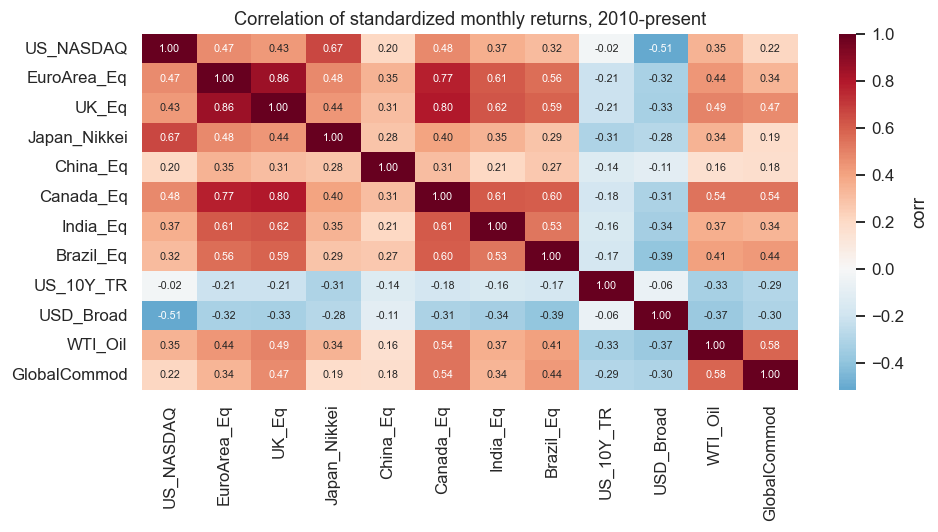

In [5]:
# Correlation heatmap of standardized monthly returns, 2010-present
fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(rets_z.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label":"corr"}, annot_kws={"size":7})
ax.set_title("Correlation of standardized monthly returns, 2010-present")
plt.tight_layout(); plt.show()

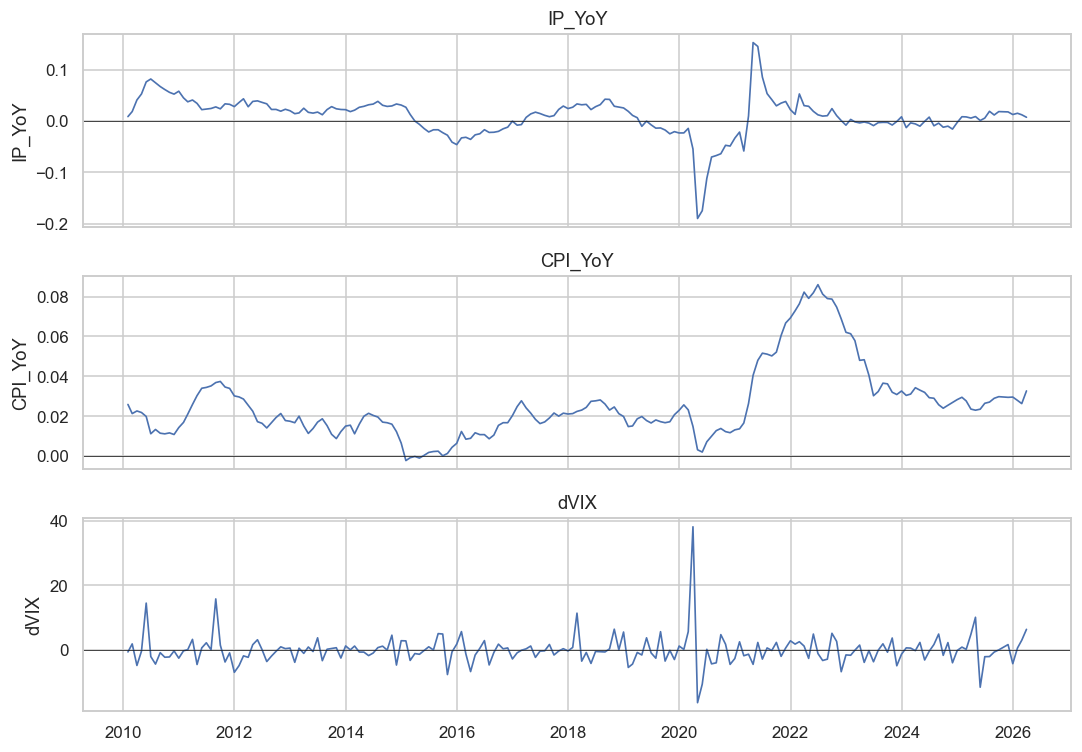

In [6]:
# Macro factor time series (3 panels)
fig, axes = plt.subplots(3,1, figsize=(10,7), sharex=True)
for ax,col in zip(axes, macro.columns):
    ax.plot(macro.index, macro[col], lw=1.1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(col); ax.set_ylabel(col)
axes[-1].set_xlabel("")
plt.tight_layout(); plt.show()

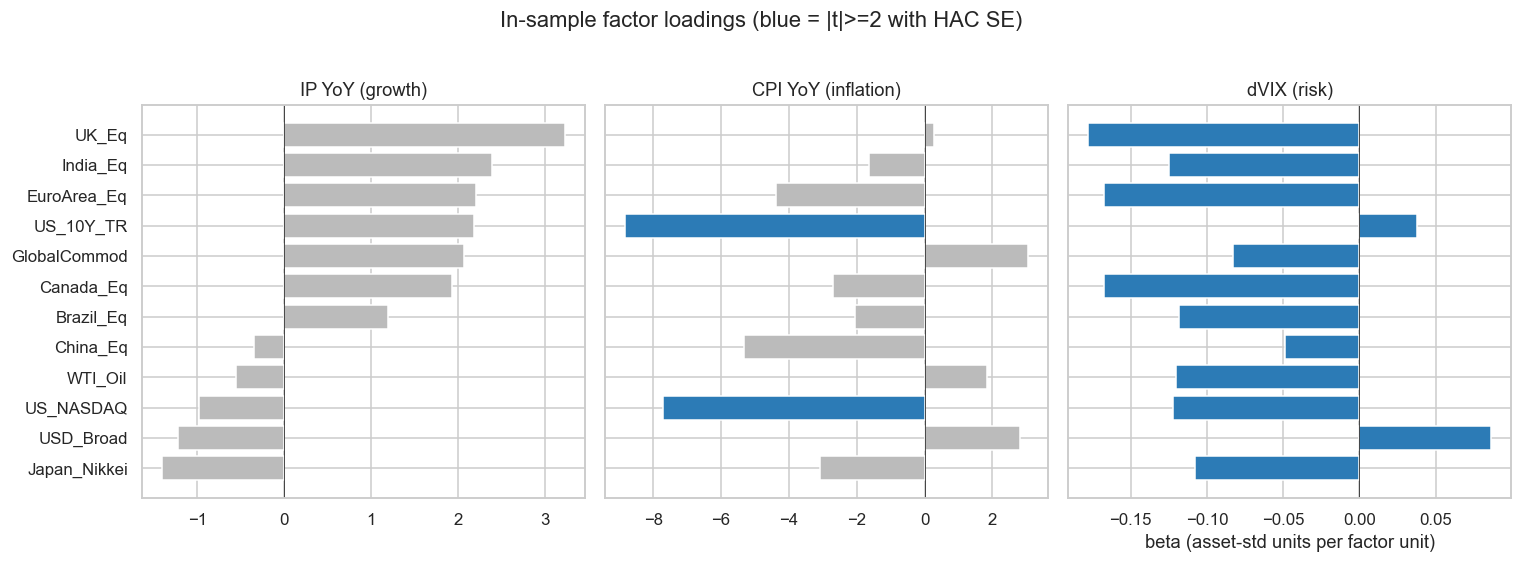

In [7]:
# In-sample factor loadings bar chart (3 panels)
fig, axes = plt.subplots(1,3, figsize=(14,5), sharey=True)
for ax, (b,t,name) in zip(axes,
        [("b_IP","t_IP","IP YoY (growth)"),
         ("b_CPI","t_CPI","CPI YoY (inflation)"),
         ("b_dVIX","t_dVIX","dVIX (risk)")]):
    s = coef_tbl.sort_values(b)
    colors = ["#2c7bb6" if abs(tv)>=2 else "#bbbbbb" for tv in s[t]]
    ax.barh(s.index, s[b], color=colors)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(name)
ax.set_xlabel("beta (asset-std units per factor unit)")
fig.suptitle("In-sample factor loadings (blue = |t|>=2 with HAC SE)", y=1.02)
plt.tight_layout(); plt.show()

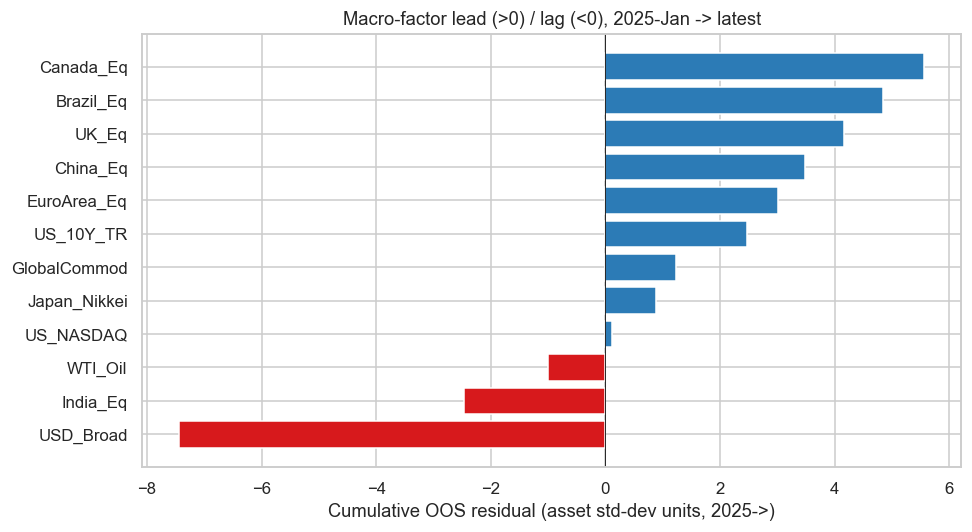

In [8]:
# OOS macro-factor lead/lag bar
fig, ax = plt.subplots(figsize=(9,5))
s = oos_summary["cum_resid_std"].sort_values()
ax.barh(s.index, s.values, color=["#d7191c" if v<0 else "#2c7bb6" for v in s])
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Cumulative OOS residual (asset std-dev units, 2025->)")
ax.set_title("Macro-factor lead (>0) / lag (<0), 2025-Jan -> latest")
plt.tight_layout(); plt.show()

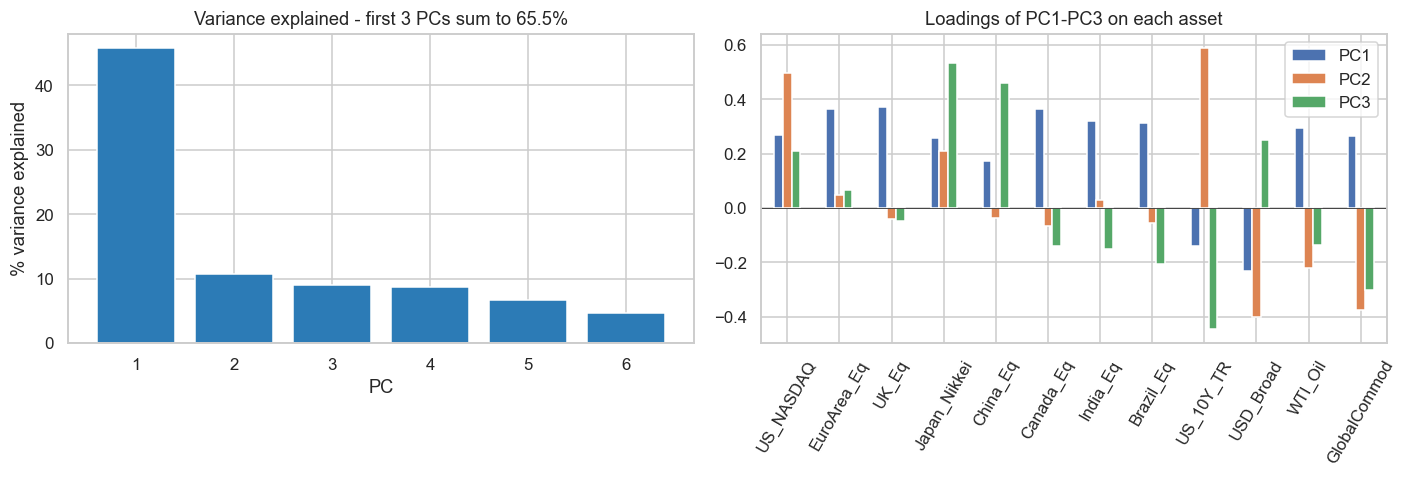

In [9]:
# PCA variance explained + loadings (2 panels)
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
axes[0].bar(range(1,len(expl)+1), expl*100, color="#2c7bb6")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("% variance explained")
axes[0].set_title(f"Variance explained - first 3 PCs sum to {expl[:3].sum()*100:.1f}%")
loadings.plot.bar(ax=axes[1])
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title("Loadings of PC1-PC3 on each asset")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

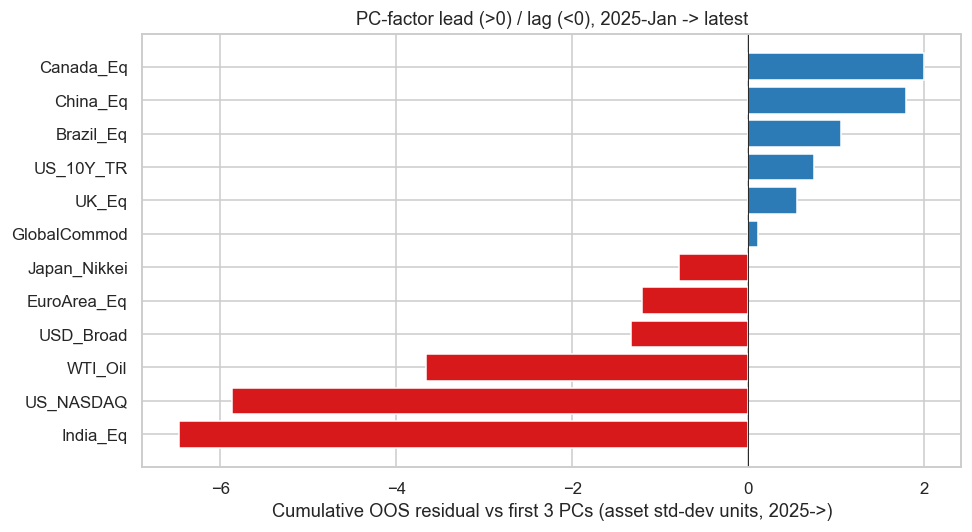

In [10]:
# PC-factor lead/lag bar
fig, ax = plt.subplots(figsize=(9,5))
s = pc_summary["cum_resid_std"].sort_values()
ax.barh(s.index, s.values, color=["#d7191c" if v<0 else "#2c7bb6" for v in s])
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Cumulative OOS residual vs first 3 PCs (asset std-dev units, 2025->)")
ax.set_title("PC-factor lead (>0) / lag (<0), 2025-Jan -> latest")
plt.tight_layout(); plt.show()